In [2]:
import os
import re
import nltk
from nltk import Tree

import spacy
#spacy.cli.download("en_core_web_sm")
# nlp = spacy.load("en_core_web_sm") 

import pandas as pd
import numpy as np

import textdescriptives as td

from dataset_evaluation.utils import add_column
from dataset_evaluation.evaluation_framework import EvaluationFramework

import folia.main as folia
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset

import pylangacq
import ast
from matplotlib.lines import Line2D

from vendi_score import text_utils

from diversity import (
	compression_ratio
)

import seaborn as sns
from matplotlib.patches import Patch

plt.style.use("seaborn-v0_8-whitegrid")

## Load datasets

### Baseline

In [2]:
baseline_data_full = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/baseline_research_prompting_llama3-8b.csv')
baseline_data_full.rename(columns={"completion": "story"}, inplace=True)
baseline_data = baseline_data_full.copy()
baseline_data = baseline_data.sample(50)

### Fewshot

In [3]:
fewshot_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/results_remote_V1/fewshot_600.csv')
fewshot_data.drop(columns=['Unnamed: 0'], inplace=True)
fewshot_data.rename(columns={'stories': "story"}, inplace=True)
fewshot_data

,system_prompt,user_prompt,demonstrations,demo_1,demo_2,demo_3,story
0,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,309_2_367,nou twee zeemeerminnen waren in de zee.\nen di...,d'r waren eens handen. \nalleen die gingen op ...,dit verhaal gaat over iemand die in een vulkaa...,nou twee orka's waren in de zee.\nen die ginge...
1,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,450_458_507,ik wou dat ik op een haai zat en die.\nen toe...,ik was met mijn stiefpapa een keer.\nik was to...,vroeger hadden de hele lange dinosaurussen die...,ik wou dat ik een konijntje was.\nen toen ging...
2,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,585_275_389,ik ging de school repareren.\ntoen was de ladd...,dat was een paard.\nen toen was een hondje.\ne...,en mijn verhaal gaat over een vliegend piraten...,Ik ging naar de zandbak.\nToen was ik zo boos ...
3,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,561_365_580,er was een kraan.\nde kraan was aan het graven...,er was een jongen en een meisje die gingen naa...,dat er een draak en een prinses in het bos war...,er was een hond\ndie had een broertje\nhet bro...
4,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,396_324_253,ik heb een vriendin en die heet Anna en daar k...,robot was een keer op reis.\nen opeens zag hij...,er was dus een ridder die heette Rik.\nen die ...,Ik heb een hond en die heet Max en die kan zwe...
...,...,...,...,...,...,...,...
595,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,542_333_315,ik heb een verhaal over een jongen en een meis...,mijn verhaal gaat over voetbal omdat ik heel e...,d'r was een tweeling die heten Japie en Jopie....,ik heb een verhaal over een mannetje en zijn h...
596,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,523_118_397,ik was thuis.\nhet ging allemaal weer goed met...,en ik wou dat ik op een draak zat. \nen ik was...,toen ik keer naar stad was toen ging ik heel v...,ik was met mijn vader op een eiland\ner waren ...
597,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,3_444_67,er was een keer een eenhoorn en die was helema...,mijn verhaal gaat over een knuffel.\ndie zogen...,ik ga een verhaal vertellen over de westerse b...,ik ga een verhaal vertellen over een konijn.\n...
598,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHier zijn 3 voorbeelden o...,296_31_47,er was een prinses en een prinsje. \nen die gi...,er was een jongen in een wereld.\nin een hele ...,en het gaat over een groot kaboutertje. \nhij ...,er was een klein konijn met een lange staart\n...


#### Persona

In [ ]:
theme_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/storytheme_research_prompting_llama3-8b.csv')

# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 1: theme == 0 ----
df_persona = (
	theme_data[theme_data["theme"] == str(0)][completion_cols]
	.melt(value_name="story", var_name="completion_number")
	.drop(columns="completion_number")
	.reset_index(drop=True)
)

persona_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/results_remote_V1/persona_prompt_600.csv')
persona_data.drop(columns=['Unnamed: 0'], inplace=True)
persona_data.rename(columns={'stories': "story"}, inplace=True)
persona_data


,system_prompt,user_prompt,story
0,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Een keer was ik bij mijn oom en tante in de ze...
1,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Ik had gisteren een eend in mijn tuin. Hij kwa...
2,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Er was eens een konijn met vlechtjes in zijn o...
3,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Ik had gisteren een ontzettend spannende dag! ...
4,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Er was eens een klein konijntje. Het had heel ...
...,...,...,...
595,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Er was eens een konijn met een rode vacht. Hij...
596,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Er was eens een knuffelbeer die heette Bert. H...
597,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Ik was vandaag in de boomgaard met mijn beste ...
598,\n Je bent een verteller van een kort verha...,Vertel een verhaal,Er was eens een prinses die een koninkrijk had...


#### Themes

In [ ]:
theme_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/storytheme_research_prompting_llama3-8b.csv')

# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 2: theme != 0 ----
df_theme = (
	theme_data[theme_data["theme"] != str(0)][["model", "theme", "system", "user"] + completion_cols]
	.melt(id_vars=["model", "theme", "system", "user"],
		  value_name="story",
		  var_name="completion_number")
	.drop(columns="completion_number")
	.reset_index(drop=True)
)

themes_data_600 = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/results_remote_V1/themes_condition_600.csv')
themes_data_600.drop(columns=['Unnamed: 0'], inplace=True)
themes_data_600.rename(columns={'stories': "story"}, inplace=True)
themes_data_600


,system_prompt,user_prompt,themes,story
0,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,verloren beschavingen,"Er was eens, in een heel erg groot bos, een st..."
1,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,virtuele werelden,We waren op school en we hadden een leuke acti...
2,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,mysterieuze kaarten,"Dus, we waren laatst bij mijn opa en oma. Hij ..."
3,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,dinosaurussen,"Een tijd lang, heel heel lang geleden... waren..."
4,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,geheime genootschappen,Een keer was ik met mijn beste vriendin Sophia...
...,...,...,...,...
595,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,culturele tradities,Er was eens een meisje genaamd Mika. Ze woonde...
596,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,tijdreizen,"We gingen op pad naar school, maar dan in onze..."
597,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,onderwateravonturen,"Er was eens een vriend van me, hij heet Timmy!..."
598,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,ongewone voertuigen,Er was eens een klein jongetje dat zijn eigen ...


### Narrative features

In [6]:
narrative_elements_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/storyelement_research_prompting_llama3-8b.csv')

# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 2: narrative_element != 0 ----
df_elements = (
	narrative_elements_data[narrative_elements_data["narrative_element"] != str(0)][["model", "narrative_element", "system", "user"] + completion_cols]
	.melt(id_vars=["model", "narrative_element", "system", "user"],
		  value_name="story",
		  var_name="completion_number")
	.drop(columns="completion_number")
	.reset_index(drop=True)
)

df_elements = df_elements.sample(50)

story_element_data_600 = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/results_remote_V1/story_elements_condition_600.csv')
story_element_data_600.drop(columns=['Unnamed: 0'], inplace=True)
story_element_data_600.rename(columns={'stories': "story"}, inplace=True)
story_element_data_600

,system_prompt,user_prompt,elements,story
0,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,circulaire verhaalsstructuur,Oké! Er was eens een konijn dat erg graag wild...
1,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,vooruitwijzing,Er was eens een prinsesje die een koninkrijk h...
2,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,een cliffhanger,Er was eens een konijn met een rood mutsje. Hi...
3,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,circulaire verhaalsstructuur,Er was eens een kleurrijk konijn. Het konijn h...
4,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,innerlijke monoloog,Er was eens een hondje genaamd Max. Hij was zo...
...,...,...,...,...
595,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,een geneste structuur,Ik weet een leuk verhaal! Er was eens een koni...
596,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,symboliek,Er was eens een prinsesje die in een groot bos...
597,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,contrast (juxtapositie),"Er was eens een kleine, lelijke kikker. Hij wo..."
598,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,circulaire verhaalsstructuur,Ik ging naar de speeltuin met mijn beste vrien...


### Additional words

In [ ]:
awords_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/additionalwords_research_prompting_llama3-8b.csv')

# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 2: theme != 0 ----
df_awords = (
	awords_data[awords_data["theme"] != str(0)][["model", "theme", "system", "user"] + completion_cols]
	.melt(id_vars=["model", "theme", "system", "user"],
		  value_name="story",
		  var_name="completion_number")
	.drop(columns="completion_number")
	.reset_index(drop=True)
)

awords_data_600 = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/results_remote_V1/chosen_words_condition_600.csv')
awords_data_600.drop(columns=['Unnamed: 0'], inplace=True)
awords_data_600.rename(columns={'stories': "story"}, inplace=True)
awords_data_600


,system_prompt,user_prompt,chosen_words,story
0,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,nijlpaard_volwassen_merkt,Er was eens een jongetje dat naar de dierentui...
1,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,mamaeend_zelfde_dobberen,Er was eens een leuke vis. Die vis ging op avo...
2,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,roetsjen_best_zinkt,Er was eens een leuke vis die heette Pip. Hij ...
3,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,verpleegster_houten_strijden,Er was eens een kleine leeuw. Hij wilde niet k...
4,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,taal_Wars_halen,Er was eens een prinses die in een kasteel woo...
...,...,...,...,...
595,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,boerderij_vast_stinken,Eén keer was ik op bezoek bij mijn vriendje To...
596,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,bakkerbevershulpjes_supergrappig_vraagt,Er was eens een bakker die supergrappige bever...
597,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,jaren_eerder_afglijden,Ik woonde in een prachtige tuin met veel appel...
598,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nHet verhaal moet het volg...,apen_dun_afveegt,Er was eens een klein meisje dat op aarde woon...


### POS-tags

In [ ]:
postag_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/fixedpos_research_prompting_llama3-8b.csv')

# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 2: theme != 0 ----
df_pos = (
	postag_data[postag_data["theme"] != str(0)][["model", "theme", "system", "user"] + completion_cols]
	.melt(id_vars=["model", "theme", "system", "user"],
		  value_name="story",
		  var_name="completion_number")
	.drop(columns="completion_number")
	.reset_index(drop=True)
)

pos_data_600 = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/results_remote_V1/pos_tags_condition_600.csv')
pos_data_600.drop(columns=['Unnamed: 0'], inplace=True)
pos_data_600.rename(columns={'stories': "story"}, inplace=True)
pos_data_600

,system_prompt,user_prompt,pos_tags,story
0,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,SPACE,Er was eens een prinsesje dat in een kasteel w...
1,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,PRON,Ik was eens op bezoek bij mijn oma in de tuin....
2,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,CCONJ,"Maar, in de stad van kleuren had ik een vriend..."
3,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,ADV,Alleen in de jungle is er een fantastische vri...
4,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,SPACE,Daarbuiten woonden de magische beren! Ze hadde...
...,...,...,...,...
595,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,CCONJ,"En toen ging ik naar de speeltuin, want mijn v..."
596,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,CCONJ,"Maar, toen ik naar de beek ging spelen, zagen ..."
597,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,ADV,Gisteren ging ik naar de speeltuin! Er was een...
598,\n Je bent een verteller van een kort verha...,Vertel een verhaal.\nBegin het verhaal met een...,ADP,In de boswandeling... ging ik samen met mijn b...


### ChiSCor

In [3]:
path_name = '/Users/sabijn/Documents/PhD/Datasets/chisor_dataset_all/ChiSCor_CoNLL_paper/csv/ChiSCor_master_df_password/ChiSCor_master_df.csv'
df_chiscor = pd.read_csv(path_name, index_col=0)
df_chiscor = df_chiscor.rename(columns={'story_raw': 'story'})

In [10]:
path_name = '/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/fewshot.csv'
df_fewshot = pd.read_csv(path_name)
df_fewshot.rename(columns={'stories': 'story'}, inplace=True)
df_fewshot.columns

Index(['Unnamed: 0', 'system_prompt', 'user_prompt', 'demonstrations',
       'demo_1', 'demo_2', 'demo_3', 'story'],
      dtype='object')

In [11]:
all_datasets = {'baseline': baseline_data, 'persona': df_persona, 'theme': df_theme, 'narrative-element': df_elements, 'a_words': df_awords, 'pos': df_pos, 'few_shot': df_fewshot, 'chiscor': df_chiscor}

In [12]:
all_600_datasets = {'baseline': baseline_data_full, 'persona': persona_data, 'theme': themes_data_600, 'narrative-element': story_element_data_600, 'a_words': awords_data_600, 'pos': pos_data_600, 'few_shot': fewshot_data, 'chiscor': df_chiscor}

### Reference corpora

In [8]:
ref_standard_dep = Path('datasets/BasiScript/BS_dep_lexicon_unk_newlemmatizer_nopronoun.csv')
ref_standard_uni = Path('datasets/BasiScript/BS_unigram_lexicon.csv')
ref_standard_bi = Path('datasets/BasiScript/BS_bigram_lexicon.csv')

In [9]:
ref_spoken_b_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_bigram.csv')
ref_spoken_u_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_unigram.csv')
ref_spoken_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_trigram.csv')

## Story quality

Overview used metrics:
- Coherence
	- Local contextuality
- Grammaticality
	- Grammaticality
- Surprise
	- Creative perplexity
- Diversity
	- Lexical diversity: self-bleu
	- lexical diversity: moving mtld
- Complexity
	- Lexical complexity: unique words
	- Lexical complexity: Average word length
	- Syntactic complexity: avg. components
	- Syntactic complexity: dependency distance
	- Syntactic complexity: syntactic tree depth

In [10]:
eval_f = EvaluationFramework(language='nl',
							  pos_unigram=ref_spoken_u_csv, 
							  pos_bigram=ref_spoken_b_csv,
							  pos_trigram=ref_spoken_t_csv,
							  ref_unigram=ref_standard_uni,
							  ref_bigram=ref_standard_bi,
							  ref_ling_constrained=ref_standard_dep,
							  embedding_model='jegormeister/bert-base-dutch-cased')

In [11]:
# Surprise: creative perplexity
eval_f.add_pipe('creative_perplexity_dep')
# Local contextuality
eval_f.add_pipe("local_contextuality")
# Grammaticality
eval_f.add_pipe('grammaticality')
# Diversity (lexical) self-bleu
eval_f.add_pipe('self-bleu')
# Diversity (lexical) moving mtld
eval_f.add_pipe('lexical_diversity')
# Complexity (lexical) unique words
eval_f.add_pipe('unique-words')
# Complexity (lexical) average word length
eval_f.add_pipe('avg-word-length')
# Complexity (syntactic)  average components
eval_f.add_pipe('average_components')
# Complexity (syntactic) dependency distance
eval_f.add_pipe('dependency_distance')
# Complexity (syntactic) syntactic tree depth
eval_f.add_pipe('syntactic_depth')
# Words before root
eval_f.add_pipe('wbr_average')

In [ ]:
def load_or_run_eval(eval_f, dataset, column, path_name, *, run=False):
	if Path(path_name).exists() and not run:
		df = pd.read_csv(path_name)
		if 'lexical_diversity' in df.columns:
			df['lexical_diversity'] = df['lexical_diversity'].apply(ast.literal_eval)
			
		return df

	dataset = eval_f.run_pipeline_on_df(dataset, column)
	dataset.to_csv(path_name, index=False)
	return dataset

In [ ]:
temp = all_datasets
for name, data in temp.items():
	print(f"Current method: {name}")
	generated_eval_results = load_or_run_eval(eval_f, data, 'story', f'results/metric_results_without_newlines/eval_results_{name}_unk.csv')
	all_datasets[name] = generated_eval_results

Current method: baseline
Current method: persona
Current method: theme
Current method: narrative-element
Current method: a_words
Current method: pos
Current method: few_shot
Current method: chiscor


### Plotting story quality

In [ ]:
nice_name = {'creative_perplexity_dep': 'Creative perplexity',
			 'local_contextuality': 'Local contextuality',
			 'grammaticality': 'Grammaticality',
			 'self-bleu': 'Self-bleu',
			 'lexical_diversity': 'Moving MTLD',
			 'unique-words': 'Size of vocabulary',
			 'avg-word-length': 'Average word length',
			 'average_components': 'Average components',
			 'dependency_distance': 'Dependency distance',
			 'syntactic_depth': 'Syntactic depth'
			 }

In [ ]:
def get_value_from_dictionary(x, key):
	new = []

	for item in x:
		new.append(item[key])
	return new

In [ ]:
for name, data in all_datasets.items():
	print(data.columns)

Index(['model', 'system', 'user', 'story', 'creative_perplexity_dep',
       'lexical_diversity'],
      dtype='object')
Index(['story', 'creative_perplexity_dep', 'lexical_diversity'], dtype='object')
Index(['model', 'theme', 'system', 'user', 'story', 'creative_perplexity_dep',
       'lexical_diversity'],
      dtype='object')
Index(['model', 'narrative_element', 'system', 'user', 'story',
       'creative_perplexity_dep', 'lexical_diversity'],
      dtype='object')
Index(['model', 'theme', 'system', 'user', 'story', 'creative_perplexity_dep',
       'lexical_diversity'],
      dtype='object')
Index(['model', 'theme', 'system', 'user', 'story', 'creative_perplexity_dep',
       'lexical_diversity'],
      dtype='object')
Index(['Unnamed: 0', 'system_prompt', 'user_prompt', 'demonstrations',
       'demo_1', 'demo_2', 'demo_3', 'story', 'creative_perplexity_dep',
       'lexical_diversity'],
      dtype='object')
Index(['id', 'story_lemmatized', 'story', 'story_raw_no_newlines', 'sto

In [ ]:
metrics = ['creative_perplexity_dep', 'local_contextuality', 'grammaticality', 'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length', 'average_components', 'dependency_distance', 'syntactic_depth']
metrics = ['creative_perplexity_dep', 'lexical_diversity']
story_metrics_means = {}

for name in all_datasets.keys():
	story_metrics_means[name] = defaultdict(float)

for name, data in all_datasets.items():
	for column in data.columns:
		if column in metrics:
			try:
				story_metrics_means[name][column] = data[column].mean()
			except:
				x = get_value_from_dictionary(data[column], 'moving_mtld')
				story_metrics_means[name][column] = np.mean(np.array(x))
story_metrics_means


{'baseline': defaultdict(float,
             {'creative_perplexity_dep': 142.37758003977095,
              'lexical_diversity': 35.74203972791508}),
 'persona': defaultdict(float,
             {'creative_perplexity_dep': 193.33869759050435,
              'lexical_diversity': 51.02560007179101}),
 'theme': defaultdict(float,
             {'creative_perplexity_dep': 183.2002757112413,
              'lexical_diversity': 53.99886503632272}),
 'narrative-element': defaultdict(float,
             {'creative_perplexity_dep': 234.61319725868037,
              'lexical_diversity': 51.83650831351451}),
 'a_words': defaultdict(float,
             {'creative_perplexity_dep': 215.11892323572502,
              'lexical_diversity': 53.05213785833389}),
 'pos': defaultdict(float,
             {'creative_perplexity_dep': 211.7895697365983,
              'lexical_diversity': 53.78462990779709}),
 'few_shot': defaultdict(float,
             {'creative_perplexity_dep': 127.91770708879442,
              'l

In [ ]:
metrics = ['creative_perplexity_dep', 'local_contextuality', 'grammaticality', 'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length', 'average_components', 'dependency_distance', 'syntactic_depth']
metrics = ['creative_perplexity_dep', 'lexical_diversity']
story_metrics_std = {}

for name in all_datasets.keys():
	story_metrics_std[name] = defaultdict(float)

for name, data in all_datasets.items():
	for column in data.columns:
		if column in metrics:
			try:
				story_metrics_std[name][column] = data[column].std()
			except:
				x = get_value_from_dictionary(data[column], 'moving_mtld')
				story_metrics_std[name][column] = np.std(np.array(x))
story_metrics_std


{'baseline': defaultdict(float,
             {'creative_perplexity_dep': 103.44890103576438,
              'lexical_diversity': 8.85282177671387}),
 'persona': defaultdict(float,
             {'creative_perplexity_dep': 96.12056445018787,
              'lexical_diversity': 10.351789083570997}),
 'theme': defaultdict(float,
             {'creative_perplexity_dep': 171.33187772951743,
              'lexical_diversity': 12.207747425486849}),
 'narrative-element': defaultdict(float,
             {'creative_perplexity_dep': 180.61456192355956,
              'lexical_diversity': 13.613211429217342}),
 'a_words': defaultdict(float,
             {'creative_perplexity_dep': 107.9954198773868,
              'lexical_diversity': 11.848192663002367}),
 'pos': defaultdict(float,
             {'creative_perplexity_dep': 191.17199603667962,
              'lexical_diversity': 11.807551675102832}),
 'few_shot': defaultdict(float,
             {'creative_perplexity_dep': 128.0298296990678,
             

In [ ]:
import pandas as pd
from pathlib import Path
from collections import Counter
import numpy as np
from simplemma import text_lemmatizer
import pylangacq
import spacy
import re

import matplotlib.pyplot as plt

class CreativePerplexity():
	def __init__(self, nlp, language, mode, unigram, bigram, constrained_bigram):
		self.nlp = nlp
		self.mode = mode
		self.language = language
		self.unigram = self._load_reference_corpora(unigram)
		self.bigram = self._load_reference_corpora(bigram)
		self.constrained_bigram = self._load_reference_corpora(constrained_bigram)

	def _load_reference_corpora(self, data_path: str) -> pd.DataFrame:
		if Path(data_path).exists():
			return pd.read_csv(data_path)
		
		raise Exception(f'Reference corpora are not registered.')
	
	def _extract_unigrams(self, story, *, with_pos=False,
					 include_punct=False, include_space=False, exclude_pos=None) -> Counter:
		"""
		Return Counter of (lemma,) or (lemma,pos) from the story.
		"""
		doc = self.nlp(story)
		bag = Counter()
		for t in doc:
			if not include_space and t.is_space: 
				continue
			if not include_punct and t.is_punct: 
				continue
			if exclude_pos and t.pos_ in exclude_pos:
				continue
			if with_pos:
				bag[(t.lemma_, t.pos_)] += 1
			else:
				bag[(t.lemma_,)] += 1
		return bag

	def _extract_bigrams(self, story):
		"""
		Return Counter of (lemma_{i-1}, lemma_i) from the story.
		"""
		doc = self.nlp(story)
		pairs = [(doc[i].lemma_, doc[i+1].lemma_) for i in range(len(doc)-1)]

		return Counter(pairs)

	def _collect_dep_pairs(self, node, bag: Counter):
		"""
		Collect linguistically constrained pairs.
		Here: (child -> head) for selected relations.
		Adjust the rules to your needs, but keep orientation consistent with lexicon.
		"""
		# Verbal heads: subject/object relations
		if node.pos_ in ('VERB', 'AUX'):
			for child in node.children:
				if child.dep_ in ('nsubj', 'nsubj:pass', 'obj')  and (child.pos_ != "PROPN" and child.pos_ != "PRON") and child.text.isalnum():
					try:
						child_lemma = text_lemmatizer(child.text, lang=self.language)[0]
						node_lemma = text_lemmatizer(node.text, lang=self.language)[0]
						bag[(child_lemma, node_lemma)] += 1
					except:
						print(child.text)
						print(node.text)
						raise
		# Nominal heads: adjectival modifiers
		if node.pos_ == 'NOUN':
			for child in node.children:
				if child.dep_ == 'amod' and child.pos_ == 'ADJ' and child.text.isalnum():
					try:
						child_lemma = text_lemmatizer(child.text, lang=self.language)[0]
						node_lemma = text_lemmatizer(node.text, lang=self.language)[0]
						bag[(child_lemma, node_lemma)] += 1
					except:
						print(child.text)
						print(node.text)
						raise

		# Recurse
		for child in node.children:
			self._collect_dep_pairs(child, bag)

	def _extract_dep_pairs(self, story):
		"""
		Return Counter of linguistically constrained (lemma1, lemma2) pairs.
		Current orientation: (dependent lemma, head lemma).
		"""
		bag = Counter()
		for sent in self.nlp(story).sents:
			self._collect_dep_pairs(sent.root, bag)
		return bag

	def _compute_unigram_perplexity_from_counts(
		self,
		story_counts: Counter,
		lexicon,
		*,
		cols=("lemma",),                # or ("lemma","pos")
		alpha: float = 1.0,
		return_frame: bool = False,
	):
		"""
		Unigram PPL with Laplace smoothing:
		p(w) = (c_corpus(w) + alpha) / (C + alpha*V)
		Weighted by story token counts.
		"""
		if not story_counts:
			return (None, pd.DataFrame(columns=[*cols,"count","freq"])) if return_frame else None

		story_df = pd.DataFrame([(*k, c) for k, c in story_counts.items()],
								columns=[*cols, "count"]) \
				.merge(lexicon, how="left", on=list(cols))
		story_df["freq"] = story_df["freq"].fillna(0).astype(np.int64)

		C = int(lexicon["freq"].sum())                                # total tokens in reference
		V = int(lexicon.drop(columns=["freq"]).drop_duplicates().shape[0]) or 1
		denom = C + alpha * V

		p = (story_df["freq"] + alpha) / denom
		logp = np.log(p)

		N = int(story_df["count"].sum())
		ppl = float(np.exp(-(logp * story_df["count"]).sum() / N))

		if return_frame:
			out = story_df.copy()
			out["prob"] = p
			return ppl, out[[*cols, "count", "freq", "prob"]]
		return ppl

	def _compute_perplexity_from_counts(
		self,
		story_counts: Counter,
		lex: pd.DataFrame,       
		*,
		smoothing: str = "kneser_ney",   
		alpha: float = 0.1,              
		unk_token: str = "<unk>",
		return_frame: bool = False
	):
		
		# Fixed vocab for lemma2 (after cutoff)
		vocab2 = set(lex['lemma2'].unique())
		global_V = len(vocab2)

		# ---------- 2) Prepare story pairs and map OOV lemma2 → <unk> ----------
		if not story_counts:
			return (None, pd.DataFrame(columns=['lemma1','lemma2','count'])) if return_frame else None

		def map_l2(l2):
			return l2 if l2 in vocab2 else unk_token

		story_pairs = [ (l1, map_l2(l2), c) for (l1, l2), c in story_counts.items() ]
		story_df = pd.DataFrame(story_pairs, columns=['lemma1','lemma2','count'])
		story_df.at[0, 'lemma2'] = '<unk>'

		# Merge training counts for these pairs
		story_df = story_df.merge(lex, how='left', on=['lemma1','lemma2'])
		story_df['freq'] = story_df['freq'].fillna(0).astype(int)

		# Totals per history
		hist_totals = lex.groupby('lemma1', as_index=False)['freq'].sum().rename(columns={'freq':'hist_total'})
		story_df = story_df.merge(hist_totals, how='left', on='lemma1')
		story_df['hist_total'] = story_df['hist_total'].fillna(0).astype(int)

		# ---------- 3A) Kneser–Ney smoothing ----------
		if smoothing == "kneser_ney":
			# Continuation counts (#distinct w1 per w2)
			cont_df = (
				lex[lex['freq'] > 0]
				.groupby('lemma2', as_index=False)['lemma1']
				.nunique()
				.rename(columns={'lemma1':'cont_count'})
			)
			cont_df = pd.DataFrame({'lemma2': list(vocab2)}).merge(cont_df, how='left', on='lemma2')
			cont_df['cont_count'] = cont_df['cont_count'].fillna(0).astype(int)

			total_types = int((lex['freq'] > 0).sum())
			cont_df['p_cont'] = np.where(
				total_types > 0,
				cont_df['cont_count'] / total_types,
				1.0 / global_V
			)

			story_df = story_df.merge(cont_df[['lemma2','p_cont']], how='left', on='lemma2')
			story_df['p_cont'] = story_df['p_cont'].fillna(1.0 / global_V)

			# Distinct followers per history
			T_df = (
				lex[lex['freq'] > 0]
				.groupby('lemma1', as_index=False)['lemma2']
				.nunique()
				.rename(columns={'lemma2':'T_followers'})
			)
			story_df = story_df.merge(T_df, how='left', on='lemma1')
			story_df['T_followers'] = story_df['T_followers'].fillna(0).astype(int)

			# Discount D
			counts = lex['freq'].values
			N1 = int(np.sum(counts == 1))
			N2 = int(np.sum(counts == 2))
			D = (N1 / (N1 + 2 * N2)) if (N1 + 2 * N2) > 0 else 0.75

			hist = story_df["hist_total"].replace(0, np.nan)  # avoid division by zero
			lam = (D * story_df["T_followers"]) / hist
			lam = lam.fillna(1.0)  # unseen history → full backoff

			hist_safe = story_df['hist_total'].replace(0, np.nan)
			first_term = np.maximum(story_df['freq'] - D, 0.0) / hist_safe
			first_term = first_term.fillna(0.0)

			probs = first_term + lam * story_df['p_cont']
			probs = np.maximum(probs, np.finfo(float).tiny)

			diag_cols = ['lemma1','lemma2','count','freq','hist_total','T_followers','p_cont']
			story_df_out = story_df[diag_cols].copy()
			story_df_out['prob'] = probs
		else:
			raise ValueError("smoothing must be 'kneser_ney' or 'add_alpha'")

		# ---------- 4) Compute perplexity ----------
		N = int(story_df['count'].sum())
		if N == 0:
			return (None, story_df_out) if return_frame else None

		avg_logp = (np.log(probs) * story_df['count']).sum() / N
		ppl = float(np.exp(-avg_logp))

		if return_frame:
			return ppl, story_df_out
		return ppl

	def _perplexity_for_creativity(
		self,
		story: str,
		*,
		alpha: float,
		vocab: str,
		with_pos_unigram: bool,   # unigram extractor option
		unigram_cols,        # or ("lemma","pos") to match your lexicon
		return_frame: bool,
	):
		"""
		General entry point. Chooses the extractor and computes perplexity.
		IMPORTANT: Your lexicon columns must match the extractor/cols:
		- unigram_cols for 'unigram'
		- ['lemma1','lemma2','freq'] for 'bigram'/'dep'
		"""
		if self.mode == "bigram":
			counts = self._extract_bigrams(story)
			return self._compute_perplexity_from_counts(
				counts, self.bigram, alpha=alpha, vocab=vocab, return_frame=return_frame
			)
		elif self.mode == "dep":
			counts = self._extract_dep_pairs(story)
			return self._compute_perplexity_from_counts(
				counts, self.constrained_bigram, alpha=alpha, return_frame=return_frame
			)
		elif self.mode == "unigram":
			counts = self._extract_unigrams(story, with_pos=with_pos_unigram)
			return self._compute_unigram_perplexity_from_counts(
				counts, self.unigram, cols=unigram_cols, alpha=alpha, return_frame=return_frame
			)
		else:
			raise ValueError("mode must be 'unigram', 'bigram', or 'dep'")
	
	def evaluate(self, text: str, vocab="per_history", alpha=1.0, with_pos_unigram=True,
				 unigram_cols=("lemma","pos"), return_frame=False
				 ) -> float:
		text = re.sub(r'\n', ' ', text).strip() # spacy dutch is hugely impacted by newlines
		text = re.sub(' +', ' ', text)
		return self._perplexity_for_creativity(text,
											   vocab=vocab,
											   alpha=alpha,
											   with_pos_unigram=with_pos_unigram,
											   unigram_cols=unigram_cols,
											   return_frame=return_frame)

In [51]:
import spacy
# nlp = spacy.load("en_core_web_sm") 
nlp = spacy.load("nl_core_news_lg") 

In [54]:
ref_standard_dep = Path('datasets/BasiScript/BS_dep_lexicon_unk_newlemmatizer_nopronoun.csv')
ref_standard_uni = Path('datasets/BasiScript/BS_unigram_lexicon.csv')
ref_standard_bi = Path('datasets/BasiScript/BS_bigram_lexicon.csv')

#  nlp, mode, unigram, bigram, constrained_bigram
ppl = CreativePerplexity(nlp, 'nl', 'dep', ref_standard_uni, ref_standard_bi, ref_standard_dep)

In [55]:
temp = all_datasets
for name, data in temp.items():
	print(f"Current method: {name}")
	all_datasets[name]['c_ppl'] = data.apply(lambda row: ppl.evaluate(row['story']), axis = 1) 
	print(all_datasets[name]['c_ppl'].mean())
	print(all_datasets[name]['c_ppl'].std())

Current method: baseline
179.21484952949086
247.50235168314165
Current method: persona
228.84739169992764
193.65204069630627
Current method: theme
242.8353486825178
327.34599831703724
Current method: narrative-element
348.47666571810566
293.4210288012798
Current method: a_words
315.34569715452375
233.56016097882554
Current method: pos
290.51478207516095
327.45168966650715
Current method: few_shot
198.58116625388956
220.51690481520734
Current method: chiscor
273.88374125493254
549.3771837867829


In [ ]:
for name, data in all_datasets.items():
	print(f"Current method: {name}")
	print(all_datasets[name]['story'][all_datasets[name]['c_ppl'])

Current method: baseline
Er was eens een klein konijn. Het konijn heette Koen. Koen woonde in een leuke bos. Op een dag ging Koen naar het bos om te spelen.

In het bos ontmoette Koen een vriendelijk eendje. De eend heette Ella. Ella was dol op water. Koen en Ella gingen samen naar het meer.

Op het meer ontmoetten Koen en Ella een vriendelijke vis. De vis heette Vinnie. Vinnie was dol op zwemmen. Koen, Ella en Vinnie speelden samen op het meer.

Koen gooide een steentje in het water. Ella sprong op en zei: "Spat!" Vinnie zwom naar boven en hiji zei: "Wauw!" Koen, Ella en Vinnie lachten allemaal samen. Ze waren blij om elkaar te hebben ontmoet.

Koen ging naar huis met Vinnie en Ella. Ze beloofden elkaar dat ze de volgende dag weer samen zouden spelen. Koen, Ella en Vinnie waren gelukkig.
Current method: persona
Er was eens een leeuw die niet kon rennen. Hij was erg snel op de weg, maar zijn pootjes waren zo zwaar dat hij op het platteland niet kon rennen. Dus besloot hij om een race t

In [62]:
for name, data in all_datasets.items():
	print(f"Current method: {name}")
	print(all_datasets[name]['c_ppl'].isna().sum())

Current method: baseline
0
Current method: persona
0
Current method: theme
0
Current method: narrative-element
0
Current method: a_words
0
Current method: pos
0
Current method: few_shot
0
Current method: chiscor
19


In [63]:
from scipy.stats import kruskal

H, p = kruskal(all_datasets['chiscor']['c_ppl'].dropna(), all_datasets['baseline']['c_ppl'], all_datasets['persona']['c_ppl'], all_datasets['theme']['c_ppl'],
	 all_datasets['narrative-element']['c_ppl'], all_datasets['a_words']['c_ppl'], all_datasets['pos']['c_ppl'], all_datasets['few_shot']['c_ppl'])
print(f"H-statistic: {H:.4f}, p-value: {p}")

H-statistic: 57.0121, p-value: 5.944715303711047e-10


In [65]:
import scikit_posthocs as sp

data = [all_datasets['chiscor']['c_ppl'].dropna(), all_datasets['baseline']['c_ppl'], all_datasets['persona']['c_ppl'], all_datasets['theme']['c_ppl'],
	 all_datasets['narrative-element']['c_ppl'], all_datasets['a_words']['c_ppl'], all_datasets['pos']['c_ppl'], all_datasets['few_shot']['c_ppl']]

# Dunn's test with Bonferroni correction
p_values = sp.posthoc_dunn(
	data,
	p_adjust="bonferroni"
)
p_values

,1,2,3,4,5,6,7,8
1,1.000000,1.000000,0.082562,1.000000,0.000193,0.000004,0.094770,1.000000
2,1.000000,1.000000,0.249886,1.000000,0.005228,0.000499,0.273778,1.000000
3,0.082562,0.249886,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,1.000000,1.000000,1.000000,1.000000,0.109599,0.016329,1.000000,1.000000
5,0.000193,0.005228,1.000000,0.109599,1.000000,1.000000,1.000000,0.051131
6,0.000004,0.000499,1.000000,0.016329,1.000000,1.000000,1.000000,0.006752
7,0.094770,0.273778,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000,0.051131,0.006752,1.000000,1.000000


## Statistical tests

In [24]:
plt.hist(all_datasets['persona']['local_contextuality'])

KeyError: 'local_contextuality'

#### Statistical local contextuality

In [ ]:
from scipy.stats import shapiro

for name, group in zip(
	["chiscor", "baseline", "persona", 'theme', 'narrative-element', 'a_words', 'pos', 'few_shot', 'chiscor'], 
	[all_datasets['chiscor']['local_contextuality'], all_datasets['baseline']['local_contextuality'], all_datasets['persona']['local_contextuality'], all_datasets['theme']['local_contextuality'],
	 all_datasets['narrative-element']['local_contextuality'], all_datasets['a_words']['local_contextuality'], all_datasets['pos']['local_contextuality'], all_datasets['few_shot']['local_contextuality']]
):
	stat, p = shapiro(group)
	print(f"Group {name} normality p-value: {p:.4f}")

Group chiscor normality p-value: 0.0000
Group baseline normality p-value: 0.9281
Group persona normality p-value: 0.9718
Group theme normality p-value: 0.4494
Group narrative-element normality p-value: 0.2285
Group a_words normality p-value: 0.0485
Group pos normality p-value: 0.0454
Group few_shot normality p-value: 0.0005


In [ ]:
from scipy.stats import kruskal

H, p = kruskal(all_datasets['chiscor']['local_contextuality'], all_datasets['baseline']['local_contextuality'], all_datasets['persona']['local_contextuality'], all_datasets['theme']['local_contextuality'],
	 all_datasets['narrative-element']['local_contextuality'], all_datasets['a_words']['local_contextuality'], all_datasets['pos']['local_contextuality'], all_datasets['few_shot']['local_contextuality'])
print(f"H-statistic: {H:.4f}, p-value: {p}")

H-statistic: 25.4900, p-value: 0.0006209977898660259


In [ ]:
import scikit_posthocs as sp

data = [all_datasets['chiscor']['local_contextuality'], all_datasets['baseline']['local_contextuality'], all_datasets['persona']['local_contextuality'], all_datasets['theme']['local_contextuality'],
	 all_datasets['narrative-element']['local_contextuality'], all_datasets['a_words']['local_contextuality'], all_datasets['pos']['local_contextuality'], all_datasets['few_shot']['local_contextuality']]

# Dunn's test with Bonferroni correction
p_values = sp.posthoc_dunn(
	data,
	p_adjust="bonferroni"
)

print(p_values)

          1         2         3        4    5    6         7         8
1  1.000000  1.000000  0.217825  0.88751  1.0  1.0  0.244675  0.027742
2  1.000000  1.000000  1.000000  1.00000  1.0  1.0  1.000000  0.332694
3  0.217825  1.000000  1.000000  1.00000  1.0  1.0  1.000000  1.000000
4  0.887510  1.000000  1.000000  1.00000  1.0  1.0  1.000000  1.000000
5  1.000000  1.000000  1.000000  1.00000  1.0  1.0  1.000000  1.000000
6  1.000000  1.000000  1.000000  1.00000  1.0  1.0  1.000000  1.000000
7  0.244675  1.000000  1.000000  1.00000  1.0  1.0  1.000000  1.000000
8  0.027742  0.332694  1.000000  1.00000  1.0  1.0  1.000000  1.000000


In [ ]:
from cliffs_delta import cliffs_delta

delta, size = cliffs_delta(all_datasets['chiscor']['local_contextuality'], all_datasets['few_shot']['local_contextuality'])
print(f"Cliff's delta = {delta:.3f}, magnitude = {size}")

Cliff's delta = 0.271, magnitude = small


#### Statistical grammaticality

In [ ]:
from scipy.stats import shapiro

for name, group in zip(
	["chiscor", "baseline", "persona", 'theme', 'narrative-element', 'a_words', 'pos', 'few_shot', 'chiscor'], 
	[all_datasets['chiscor']['grammaticality'], all_datasets['baseline']['grammaticality'], all_datasets['persona']['grammaticality'], all_datasets['theme']['grammaticality'],
	 all_datasets['narrative-element']['grammaticality'], all_datasets['a_words']['grammaticality'], all_datasets['pos']['grammaticality'], all_datasets['few_shot']['grammaticality']]
):
	stat, p = shapiro(group)
	print(f"Group {name} normality p-value: {p:.4f}")

Group chiscor normality p-value: 0.0000
Group baseline normality p-value: 0.1630
Group persona normality p-value: 0.6900
Group theme normality p-value: 0.7579
Group narrative-element normality p-value: 0.3173
Group a_words normality p-value: 0.9889
Group pos normality p-value: 0.1427
Group few_shot normality p-value: 0.4849


In [ ]:
from scipy.stats import kruskal

H, p = kruskal(all_datasets['chiscor']['grammaticality'], all_datasets['baseline']['grammaticality'], all_datasets['persona']['grammaticality'], all_datasets['theme']['grammaticality'],
	 all_datasets['narrative-element']['grammaticality'], all_datasets['a_words']['grammaticality'], all_datasets['pos']['grammaticality'], all_datasets['few_shot']['grammaticality'])
print(f"H-statistic: {H:.4f}, p-value: {p}")

H-statistic: 19.4176, p-value: 0.006975125790148987


In [ ]:
from scipy.stats import f_oneway

F, p = f_oneway(all_datasets['chiscor']['grammaticality'], all_datasets['baseline']['grammaticality'], all_datasets['persona']['grammaticality'], all_datasets['theme']['grammaticality'],
	 all_datasets['narrative-element']['grammaticality'], all_datasets['a_words']['grammaticality'], all_datasets['pos']['grammaticality'], all_datasets['few_shot']['grammaticality'])

print(f"F-statistic: {F:.4f}")
print(f"p-value: {p:.4f}")

F-statistic: 2.7086
p-value: 0.0088


In [ ]:
import scikit_posthocs as sp

data = [all_datasets['chiscor']['grammaticality'], all_datasets['baseline']['grammaticality'], all_datasets['persona']['grammaticality'], all_datasets['theme']['grammaticality'],
	 all_datasets['narrative-element']['grammaticality'], all_datasets['a_words']['grammaticality'], all_datasets['pos']['grammaticality'], all_datasets['few_shot']['grammaticality']]

# Dunn's test with Bonferroni correction
p_values = sp.posthoc_dunn(
	data,
	p_adjust="bonferroni"
)

print(p_values)

          1         2         3         4    5         6         7         8
1  1.000000  0.499153  1.000000  1.000000  1.0  1.000000  1.000000  0.260809
2  0.499153  1.000000  1.000000  1.000000  1.0  1.000000  1.000000  0.007254
3  1.000000  1.000000  1.000000  1.000000  1.0  1.000000  1.000000  0.037764
4  1.000000  1.000000  1.000000  1.000000  1.0  1.000000  1.000000  0.204504
5  1.000000  1.000000  1.000000  1.000000  1.0  1.000000  1.000000  1.000000
6  1.000000  1.000000  1.000000  1.000000  1.0  1.000000  1.000000  0.475857
7  1.000000  1.000000  1.000000  1.000000  1.0  1.000000  1.000000  0.079229
8  0.260809  0.007254  0.037764  0.204504  1.0  0.475857  0.079229  1.000000


In [ ]:
from cliffs_delta import cliffs_delta

delta, size = cliffs_delta(all_datasets['baseline']['grammaticality'], all_datasets['few_shot']['grammaticality'])
print(f"Cliff's delta = {delta:.3f}, magnitude = {size}")

Cliff's delta = -0.398, magnitude = medium


## Dataset quality

### Compression and Vendi

In [ ]:
dataset_statistics = {}
for name in all_datasets.keys():
	dataset_statistics[name] = defaultdict(float)

for name, data in all_datasets.items():
	embed_vs = text_utils.embedding_vendi_score(list(map(str, data['story'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
	dataset_statistics[name]['vendi'] = embed_vs
	print('Compression')
	comp_score = compression_ratio(data['story'].to_list(), algorithm='gzip')
	dataset_statistics[name]['compression'] = comp_score

Compression
Compression
Compression
Compression
Compression
Compression
Compression
Compression


In [ ]:
df_dataset_statistics = pd.DataFrame.from_dict(dataset_statistics, orient="index")

## Heatmaps story quality

In [ ]:
df_story_statistics = pd.DataFrame.from_dict(story_metrics_means, orient="index")
df_story_statistics

,creative_perplexity_dep,local_contextuality,grammaticality,self-bleu,lexical_diversity,unique-words,avg-word-length,average_components,dependency_distance,syntactic_depth
baseline,430.821514,0.358359,-2.192770,0.201253,36.173879,73.580000,4.020365,0.171795,2.421759,2.284519
persona,442.220198,0.332947,-2.175602,0.158082,51.025600,86.240000,4.107954,0.280538,2.803939,2.719078
theme,437.304630,0.338370,-2.162699,0.187715,53.998865,92.380000,4.081710,0.302682,2.834819,2.774724
narrative-element,748.474182,0.347733,-2.149278,0.164540,50.505157,85.860000,4.056236,0.377250,3.008379,2.791381
a_words,565.219905,0.351881,-2.154539,0.160481,53.052138,85.680000,4.143690,0.421013,2.942143,2.936726
pos,562.379704,0.335524,-2.171542,0.145021,53.784630,83.300000,4.082153,0.336785,2.843271,2.723234
few_shot,725.887069,0.308514,-2.112527,0.114601,56.452122,63.740000,3.750034,0.415612,2.963224,2.829931
chiscor,695.800719,0.356750,-2.151842,0.160073,30.334225,58.499192,3.699656,0.277128,2.656539,2.365181


In [ ]:
df_story_normalized = (df_story_statistics - df_story_statistics.min()) / (df_story_statistics.max() - df_story_statistics.min())

df_story_normalized['self-bleu'] = 1 - df_story_normalized['self-bleu']
df_story_normalized

,creative_perplexity_dep,local_contextuality,grammaticality,self-bleu,lexical_diversity,unique-words,avg-word-length,average_components,dependency_distance,syntactic_depth
baseline,0.000000,1.000000,0.000000,0.000000,0.223588,0.445114,0.722261,0.000000,0.000000,0.000000
persona,0.035884,0.490177,0.213942,0.498213,0.792230,0.818776,0.919518,0.436338,0.651495,0.666290
theme,0.020409,0.598963,0.374749,0.156231,0.906070,1.000000,0.860417,0.525191,0.704135,0.751610
narrative-element,1.000000,0.786804,0.541995,0.423679,0.772303,0.807561,0.803047,0.824400,1.000000,0.777150
a_words,0.423099,0.870031,0.476433,0.470526,0.869822,0.802248,1.000000,1.000000,0.887089,1.000000
pos,0.414157,0.541876,0.264537,0.648938,0.897867,0.732002,0.861413,0.662032,0.718544,0.672662
few_shot,0.928894,0.000000,1.000000,1.000000,1.000000,0.154684,0.113457,0.978331,0.923026,0.836256
chiscor,0.834179,0.967715,0.510052,0.475230,0.000000,0.000000,0.000000,0.422656,0.400225,0.123675


### Relative to baseline

In [ ]:
baseline_row = df_story_statistics.loc["baseline"]

# absolute difference
df_diff_baseline = df_story_statistics.subtract(baseline_row)
df_norm_diff_baseline = (df_diff_baseline - df_diff_baseline.min()) / (df_diff_baseline.max() - df_diff_baseline.min())

# relative (%) difference
df_rel_baseline = (df_story_statistics - baseline_row) / baseline_row * 100

### Relative to ChiSCor

In [ ]:
chiscor_row = df_story_statistics.loc["chiscor"]

# absolute difference
df_diff_chiscor = df_story_statistics.subtract(chiscor_row)
df_norm_diff_chiscor = (df_diff_chiscor - df_diff_chiscor.min()) / (df_diff_chiscor.max() - df_diff_chiscor.min())

# relative (%) difference
df_rel_chiscor = (df_story_statistics - chiscor_row) / chiscor_row * 100

In [ ]:
from collections import OrderedDict

metric_to_group = { "Creative PPL.": "Surprise", "Self-BLEU": "Diversity", "Moving MTLD": "Diversity", "Amount of Unique Words": "Complexity", "Average Word Length": "Complexity", "Average Components": "Complexity", "Dependency Distance": "Complexity", "Syntactic Tree Depth": "Complexity"}

group_colors = {
	"Surprise":   "#f58a42",
	"Diversity":  "#2167AC",
	"Complexity": "#62B64F",
}

def plot_heatmap(
	data,
	row_rename_dict,
	column_rename_dict,
	xlabel="Metrics",
	ylabel="Prompt Elements",
	save_name=None,
):
	df_plot = data.copy()
	df_plot.drop(columns=['grammaticality', 'local_contextuality'], inplace=True)

	df_plot = df_plot.rename(index=row_rename_dict)
	df_plot = df_plot.rename(columns=column_rename_dict)

	plt.figure(figsize=(8, 4))

	ax = sns.heatmap(
		df_plot,
		annot=True,
		fmt=".2f",
		cmap="RdBu_r",
		center=0,
		linewidths=.5,
		cbar=False
	)

	# ---- COLUMN GROUP SEPARATORS ----
	# Get group per column in the displayed order
	# col_groups = [metric_to_group.get(c, None) for c in df_plot.columns]

	# # Find boundaries where group changes (draw a line between col i-1 and i)
	# boundaries = [i for i in range(1, len(col_groups)) if col_groups[i] != col_groups[i - 1]]

	# # Draw thicker vertical lines at those boundaries
	# for x in boundaries:
	#     ax.vlines(x, *ax.get_ylim(), linewidth=3, color='white')

	# ---- ROW SEPARATORS ----
	sep_y = df_plot.shape[0] - 1  # boundary between rows (n-2) and (n-1)
	ax.hlines(sep_y, *ax.get_xlim(), linewidth=5, color='white')

	# ---- COLORED GROUP STRIP ----
	col_groups = [metric_to_group.get(c) for c in df_plot.columns]

	# y-position above the heatmap
	y0 = -0.25
	y1 = -0.05

	for i, group in enumerate(col_groups):
		color = group_colors.get(group, "lightgray")
		ax.add_patch(
			plt.Rectangle(
				(i, y0), 1, y1 - y0,
				facecolor=color,
				edgecolor="none",
				transform=ax.transData,
				clip_on=False
			)
		)
	
	# ---- GROUP COLOR LEGEND ----
	handles = [
		Patch(facecolor=color, edgecolor="none", label=group)
		for group, color in group_colors.items()
	]

	ax.legend(
		handles=handles,
		loc="upper center",
		bbox_to_anchor=(0.5, 1.20),  # above group labels
		ncol=len(handles),
		frameon=False,
		title="Metric Groups"
	)

	plt.xlabel(xlabel)
	plt.ylabel(ylabel)

	# Rotate column labels
	plt.xticks(rotation=45, ha='right')

	if save_name:
		plt.savefig(save_name)  

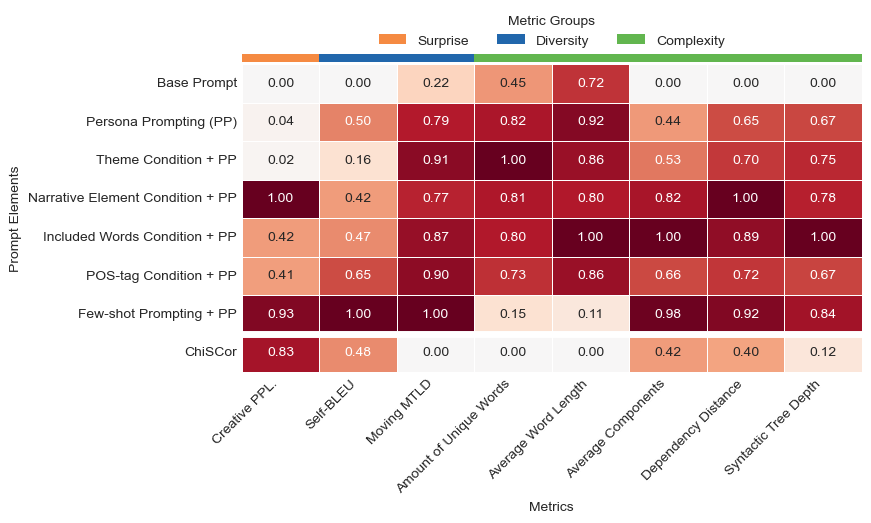

In [ ]:
# Human readable labels
rename_dict = {
	"creative_perplexity_dep": "Creative PPL.",
	"self-bleu": "Self-BLEU",
	"lexical_diversity": "Moving MTLD",
	"unique-words": "Amount of Unique Words",
	"avg-word-length": "Average Word Length",
	"average_components": "Average Components",
	"dependency_distance": "Dependency Distance",
	"syntactic_depth": "Syntactic Tree Depth",
}

row_rename_dict = {
	"baseline": "Base Prompt",
	"persona": "Persona Prompting (PP)",
	"theme": "Theme Condition + PP",
	"narrative-element": "Narrative Element Condition + PP",
	"a_words": "Included Words Condition + PP",
	"pos": "POS-tag Condition + PP",
	"few_shot": "Few-shot Prompting + PP",
	"chiscor": "ChiSCor"
}

save_path = "results/paper_plots/metrics_heatmap.pdf"
plot_heatmap(df_story_normalized, row_rename_dict, rename_dict)

## SimLex-999

In [ ]:
from gensim.models import Word2Vec
# from gensim.models.doc2vec import TaggedDocument
# from gensim.models import Doc2Vec
from sklearn.manifold import TSNE
from simplemma import text_lemmatizer
from adjustText import adjust_text

In [ ]:
simlex999 = pd.read_csv('dataset_evaluation/modelasametric/SimLex-999-Dutch-final.txt', names=['lemma1','lemma2','SimLexScore','POS'], skiprows=1, sep='\t')
simlex999.drop(index=364, inplace=True)

In [ ]:
from simplemma import text_lemmatizer
nlp = spacy.load("nl_core_news_lg") 

# function to clean raw stories
def lemmatize(data):
	sents = []
	for story in data:
		lines = list(nlp(story).sents)

		for sent in lines:
			words = []
			for w in sent:
				if w.is_alpha:
					try:
						lemma = text_lemmatizer(w.text.lower(), lang='nl')[0]
					except:
						lemma = w.lemma_.lower()
					words.append(lemma)
			sents.append(words)

	return sents

def train_and_save_w2v(data, save_name, mincount=10, callbacks=[]):
	if Path(save_name).exists():
		return Word2Vec.load(save_name)

	# list of sents of all stories
	sents = lemmatize(data)

	# train w2v
	model = Word2Vec(sents, 
						min_count=mincount, 
						window=5, 
						vector_size=100, 
						negative=5, 
						seed=42, 
						workers=1, 
						sg=0, 
						alpha=0.001, 
						epochs=500,
						callbacks=callbacks)
	
	model.save(save_name)

	return model


In [ ]:
def compute_similarity(lemma_list, model):
	pairs = lemma_list
	cos_sim = []

	for pair in pairs:
		cos_sim.append(model.wv.similarity(pair[0], pair[1]))

	return cos_sim

In [ ]:
def select_invocab_simlex(simlex: pd.DataFrame, models: Word2Vec, sample=None):
	vocab_sets = [set(model.wv.key_to_index) for model in models]
	shared_vocab = set.intersection(*vocab_sets)

	in_vocab_simlex = simlex[
		simlex["lemma1"].isin(shared_vocab) &
		simlex["lemma2"].isin(shared_vocab)
	]

	if sample:
		in_vocab_simlex = in_vocab_simlex.sample(sample)
		
	# Outputs
	word_list = list(set(in_vocab_simlex["lemma1"]).union(in_vocab_simlex["lemma2"]))
	word_pairs = list(in_vocab_simlex[["lemma1", "lemma2"]].itertuples(index=False, name=None))

	return in_vocab_simlex, word_list, word_pairs

In [ ]:
from itertools import combinations
from scipy.stats import spearmanr

def pairwise_spearman(sim_lists):
	"""
	sim_lists: list of 1D arrays/lists, one per model.
			   e.g. [sims_model1, sims_model2, sims_model3, ...]
	
	Returns: dict with ((i, j) -> spearman_r)
	"""
	results = {}
	names = list(sim_lists.keys())
	similarities = list(sim_lists.values())

	for i, j in combinations(range(len(similarities)), 2):
		r, p = spearmanr(similarities[i], similarities[j])
		results[(names[i], names[j])] = {"rho": r, "p": p}

	return results

In [ ]:
# initialise word2vec model
mincount = 10
trained_models = {}

for name, data in all_600_datasets.items():
	model = train_and_save_w2v(data['story'], f'dataset_evaluation/modelasametric/story_Word2Vec_{name}_mincount{mincount}.kv', mincount=mincount)
	trained_models[name] = model

In [ ]:
best_datasets_models = {name: model for name, model in trained_models.items() if name in ['chiscor', 'baseline', 'few_shot', 'a_words']}
best_datasets_models


{'baseline': <gensim.models.word2vec.Word2Vec at 0x348ba29f0>,
 'a_words': <gensim.models.word2vec.Word2Vec at 0x3a42772f0>,
 'few_shot': <gensim.models.word2vec.Word2Vec at 0x3a43d5880>,
 'chiscor': <gensim.models.word2vec.Word2Vec at 0x3a43e09b0>}

In [ ]:
df_filtered_simlex, filtered_simlex_list, filtered_simlex_tuple = select_invocab_simlex(simlex999, best_datasets_models.values())
len(filtered_simlex_tuple)

22

In [ ]:
df_filtered_simlex

,lemma1,lemma2,SimLexScore,POS
0,oud,nieuw,1.94,A
6,gelukkig,blij,7.09,A
26,gelukkig,boos,0.98,A
54,boos,blij,2.16,A
75,nieuw,oud,2.18,A
77,gelukkig,jong,1.78,A
216,jongen,kind,3.78,N
330,man,vader,4.31,N
422,man,kind,1.85,N
447,vriend,jongen,3.37,N


In [ ]:
cosine_similarities = {}
for name, model in best_datasets_models.items():
	cosine_similarities[name] = compute_similarity(filtered_simlex_tuple, model)

cosine_similarities['simlex999'] = df_filtered_simlex['SimLexScore']
statistic_results = pairwise_spearman(cosine_similarities)
statistic_results

{('baseline', 'a_words'): {'rho': 0.7218767665347654,
  'p': 0.00014902315863335116},
 ('baseline', 'few_shot'): {'rho': 0.6302996042962126,
  'p': 0.0016647835949736942},
 ('baseline', 'chiscor'): {'rho': 0.3736574335782928,
  'p': 0.08671450724759591},
 ('baseline', 'simlex999'): {'rho': 0.4063294878235062,
  'p': 0.06058713238585261},
 ('a_words', 'few_shot'): {'rho': 0.7150932730356133,
  'p': 0.0001837611845325991},
 ('a_words', 'chiscor'): {'rho': 0.47540983606557374,
  'p': 0.025342775884778995},
 ('a_words', 'simlex999'): {'rho': 0.16388811052686622,
  'p': 0.4661346328950914},
 ('few_shot', 'chiscor'): {'rho': 0.16449971735443752,
  'p': 0.46444932764803026},
 ('few_shot', 'simlex999'): {'rho': 0.1531506136302784,
  'p': 0.49622558061853816},
 ('chiscor', 'simlex999'): {'rho': 0.5555241815445155,
  'p': 0.007272362769520525}}

In [ ]:
comparison_simlex = {}
for key, value in statistic_results.items():
	if key[0] == 'simlex999' or key[1] == 'simlex999':
		comparison_simlex[key] = value
comparison_simlex

{('baseline', 'simlex999'): {'rho': 0.4063294878235062,
  'p': 0.06058713238585261},
 ('a_words', 'simlex999'): {'rho': 0.16388811052686622,
  'p': 0.4661346328950914},
 ('few_shot', 'simlex999'): {'rho': 0.1531506136302784,
  'p': 0.49622558061853816},
 ('chiscor', 'simlex999'): {'rho': 0.5555241815445155,
  'p': 0.007272362769520525}}

In [ ]:
from typing import List

def create_tsne_projections(model, lemmas: List, *, plotting=True, title=None, use_pretrained=False):
	vocab = list(model.wv.key_to_index)

	if use_pretrained:
		X = []
		for w in vocab:
			X.append(nlp(w).vector)
		X = np.array(X)
	else:
		X = model.wv[vocab]

	tsne = TSNE(n_components=2, random_state=42, perplexity=5)
	X_tsne = tsne.fit_transform(X)

	df_tsne = pd.DataFrame(X_tsne, index=vocab, columns=['x', 'y'])
	df_tsne = df_tsne.loc[lemmas]

	if plotting:
		fig, ax = plt.subplots(figsize=(10, 4))
		sns.regplot(x='x', y='y', data=df_tsne, scatter=True, fit_reg=False, x_jitter=0.4, y_jitter=0.4)
		ax.set(xlabel='', ylabel='')
		ax.tick_params(left=True,
						bottom=True,
						labelleft=False,
						labelbottom=False)
		ax.set_title(title)

		texts = []
		for x, y, word in zip(df_tsne['x'], df_tsne['y'], df_tsne.index):
			text = plt.text(x, y, word)
			texts.append(text)

		adjust_text(texts)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


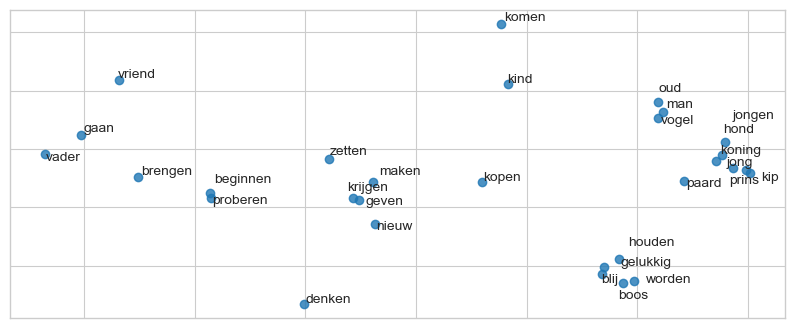

In [ ]:
create_tsne_projections(trained_models['few_shot'], filtered_simlex_list)

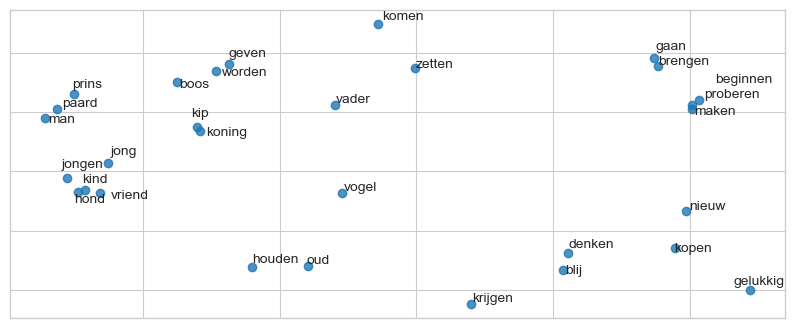

In [ ]:
create_tsne_projections(trained_models['chiscor'], filtered_simlex_list)

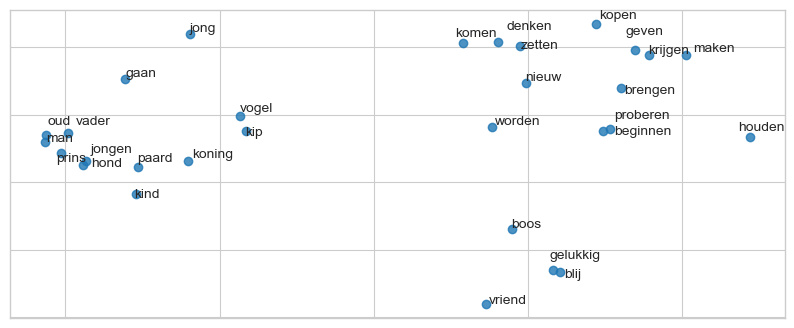

In [ ]:
create_tsne_projections(trained_models['baseline'], filtered_simlex_list)

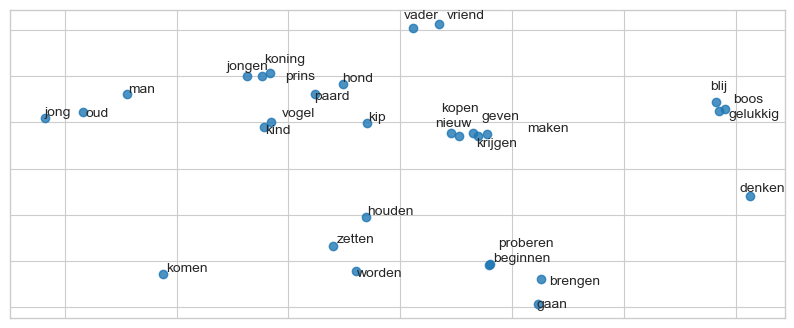

In [ ]:
create_tsne_projections(trained_models['a_words'], filtered_simlex_list)

In [ ]:
df_filtered_simlex


,lemma1,lemma2,SimLexScore,POS
0,oud,nieuw,1.94,A
6,gelukkig,blij,7.09,A
26,gelukkig,boos,0.98,A
54,boos,blij,2.16,A
75,nieuw,oud,2.18,A
77,gelukkig,jong,1.78,A
216,jongen,kind,3.78,N
330,man,vader,4.31,N
422,man,kind,1.85,N
447,vriend,jongen,3.37,N


In [ ]:
# vocab_obj = w2v.vocab["word"]
# vocab_obj.count


for (lemma1, lemma2) in filtered_simlex_tuple:
	print('**********************************')
	for name, model in trained_models.items():
		print(f'Model {name}, Lemma 1 ({lemma1}) count {model.wv.get_vecattr(lemma1, "count")} & Lemma 2 ({lemma2}) count {model.wv.get_vecattr(lemma2, "count")}')

**********************************
Model baseline, Lemma 1 (oud) count 38 & Lemma 2 (nieuw) count 73
Model persona, Lemma 1 (oud) count 67 & Lemma 2 (nieuw) count 54
Model theme, Lemma 1 (oud) count 219 & Lemma 2 (nieuw) count 52
Model narrative-element, Lemma 1 (oud) count 158 & Lemma 2 (nieuw) count 53
Model a_words, Lemma 1 (oud) count 89 & Lemma 2 (nieuw) count 68
Model pos, Lemma 1 (oud) count 67 & Lemma 2 (nieuw) count 56
Model few_shot, Lemma 1 (oud) count 40 & Lemma 2 (nieuw) count 37
Model chiscor, Lemma 1 (oud) count 42 & Lemma 2 (nieuw) count 51
**********************************
Model baseline, Lemma 1 (gelukkig) count 256 & Lemma 2 (blij) count 548
Model persona, Lemma 1 (gelukkig) count 50 & Lemma 2 (blij) count 98
Model theme, Lemma 1 (gelukkig) count 31 & Lemma 2 (blij) count 83
Model narrative-element, Lemma 1 (gelukkig) count 44 & Lemma 2 (blij) count 69
Model a_words, Lemma 1 (gelukkig) count 60 & Lemma 2 (blij) count 113
Model pos, Lemma 1 (gelukkig) count 55 & Lemm

KeyError: "Key 'jongen' not present"

45
45
45
45


{('baseline', 'simlex'): {'rho': 0.31048227697983927,
  'p': 0.03791455145476259},
 ('a_words', 'simlex'): {'rho': 0.06667105884420324, 'p': 0.6634591455490204},
 ('few_shot', 'simlex'): {'rho': 0.13147751613130174,
  'p': 0.38929041205406456},
 ('chiscor', 'simlex'): {'rho': 0.3627738430563505, 'p': 0.014319242314748435}}

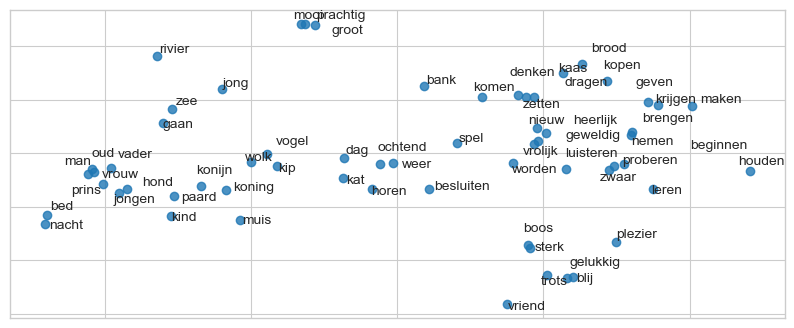

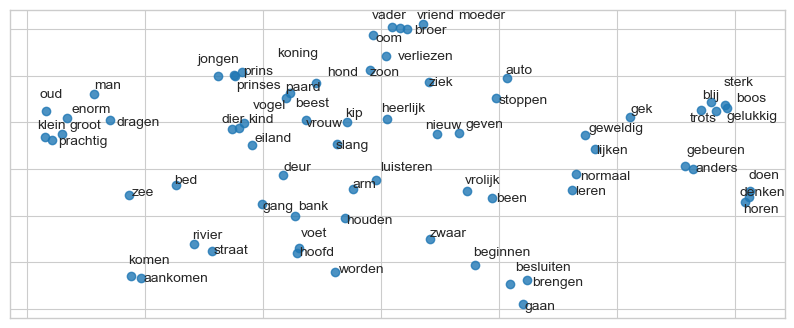

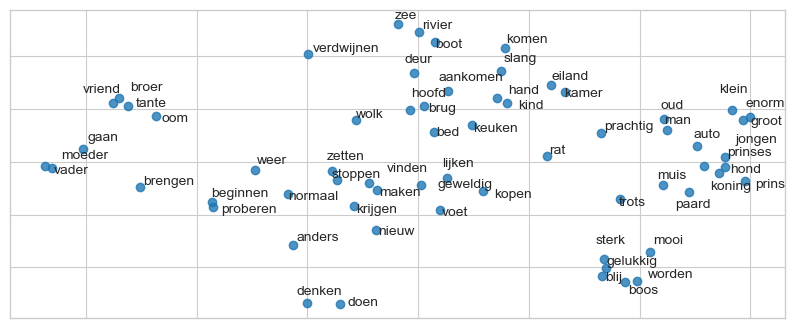

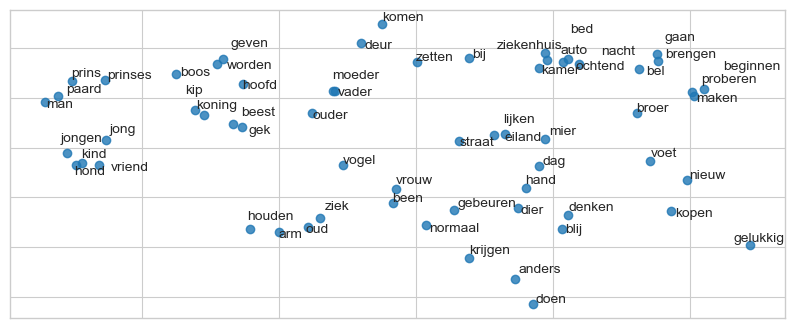

In [ ]:
cosine_similarities = {}
chosen_lemmas = {}
results = {}
amount_of_words = defaultdict(list)

for name, model in best_datasets_models.items():
	df_filtered_simlex, filtered_simlex_list, filtered_simlex_tuple = select_invocab_simlex(simlex999, [model], sample=45)
	create_tsne_projections(model, filtered_simlex_list)
	chosen_lemmas[name] = df_filtered_simlex
	cosine_similarities[name] = compute_similarity(filtered_simlex_tuple, model)
	r, p = spearmanr(cosine_similarities[name], df_filtered_simlex['SimLexScore'])
	print(len(chosen_lemmas[name]))
	results[(name, 'simlex')] = {"rho": r, "p": p}

	for (lemma1, lemma2) in filtered_simlex_tuple:
		amount_of_words[name].extend([model.wv.get_vecattr(lemma1, "count"), model.wv.get_vecattr(lemma2, "count")])
results

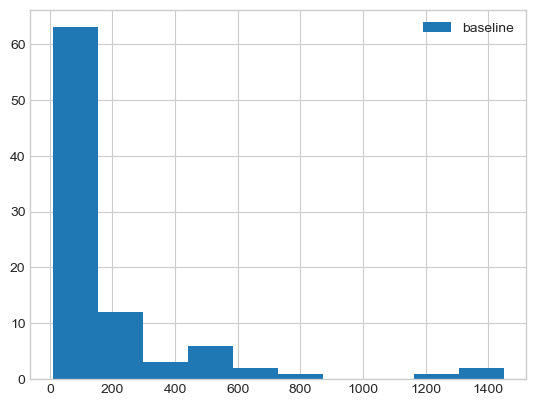

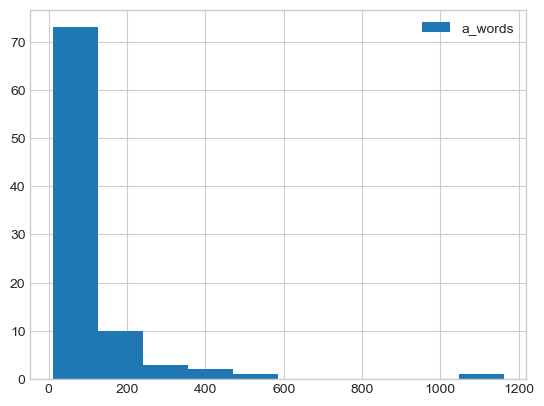

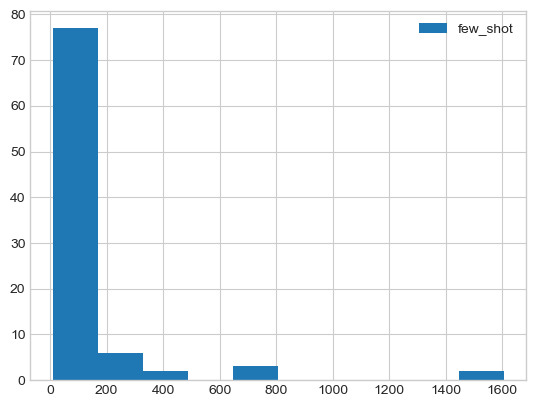

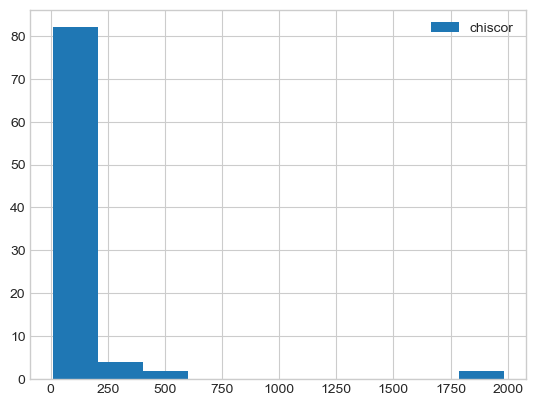

In [ ]:
for key, value in amount_of_words.items():
	plt.figure()
	plt.hist(value, label=key)
	plt.legend()
	

## Age groups

In [4]:
# Add ChiSCor mean

	### Group ###                                                      
	# group 1-2 (4-6 years:) -> (1 and 2 are always combined)           
	# group 3 (6-7)                                                     
	# group 4 (7-8)                                                     
	# group 5 (8-9)                                                     
	# group 6 (9-10)                                                    
	# group 7 (10-11)                                                   
	# group 8 (11-12)    

def agegroup_strings(value):

	if value == 1:
		return '4 - 6'
	if value == 3:
		return '6 - 7'
	if value == 4:
		return '7 - 8'
	if value == 5:
		return '8 - 9'
	if value == 6:
		return '9 - 10'
	if value == 7:
		return '10 - 11'
	if value == 8:
		return '11 - 12'

add_column('agegroup', 'agegroup_str', agegroup_strings, df_chiscor)

df_chiscor.agegroup_str = pd.Categorical(
	df_chiscor.agegroup_str,
	categories=['4 - 6', '6 - 7', '7 - 8', '8 - 9', '9 - 10', '10 - 11', '11 - 12'],
	ordered=True
)

In [6]:
def different_stripe(x):
	first = str(x).split("_")[0]
	second = str(x).split("_")[1]
	return f'{first} - {second}'

age_llama = pd.read_csv('prompting/prompting_results/age_research_test_mistake.csv')
age_llama.drop(columns=['Unnamed: 0'], inplace=True)
age_llama['age'] = age_llama['age'].apply(lambda age: different_stripe(age))
age_llama

,model,age,story
0,meta-llama/llama-3.1-8b-instruct,4 - 6,We waren in het bos met papa. Hij had een zak ...
1,meta-llama/llama-3.1-8b-instruct,4 - 6,Er was eens een eend genaamd Eddie. Eddie was ...
2,meta-llama/llama-3.1-8b-instruct,4 - 6,Er was eens een prinsesje met een mooi paard. ...
3,meta-llama/llama-3.1-8b-instruct,4 - 6,Er was eens een prinsesje met een prachtig paa...
4,meta-llama/llama-3.1-8b-instruct,4 - 6,Er was eens een leuke beer genaamd Bertie. Hij...
...,...,...,...
107,meta-llama/llama-3.1-8b-instruct,11 - 12,Er was eens een magische dolfijn genaamd Delph...
108,meta-llama/llama-3.1-8b-instruct,11 - 12,We waren op een kampeertrip met onze klas. We ...
109,meta-llama/llama-3.1-8b-instruct,11 - 12,Er was eens een jonge magische vogel. Hij heet...
110,meta-llama/llama-3.1-8b-instruct,11 - 12,"Er was een keer in een afgelegen dorpje, waar ..."


In [12]:
age_llama['DD'] = age_llama.apply(lambda row: eval_f.run_component('dependency_distance', row['story']), axis = 1) 

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_1870/1122329481.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))


    age_group  dep_dist             source
0     10 - 11  2.950920  Generated stories
1     10 - 11  3.126761  Generated stories
2     10 - 11  2.916667  Generated stories
3     10 - 11  2.896226  Generated stories
4     10 - 11  2.794737  Generated stories
..        ...       ...                ...
726   11 - 12  2.392857            ChiSCor
727     7 - 8  2.840278            ChiSCor
728     7 - 8  2.675926            ChiSCor
729     7 - 8  2.842105            ChiSCor
730     7 - 8  4.105263            ChiSCor

[731 rows x 3 columns]


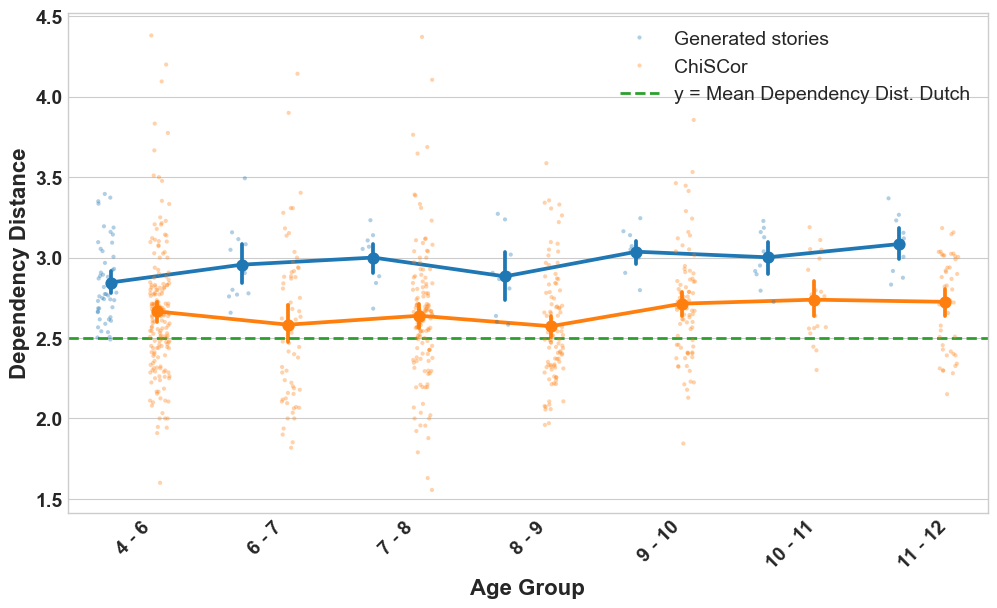

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1) Sample max 50 per age group for generated stories (age_llama) ---
df_llama = (
	age_llama.groupby("age", group_keys=False)
	  .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
	  .loc[:, ["age", "DD"]]
	  .rename(columns={"age": "age_group", "DD": "dep_dist"})
)
df_llama["source"] = "Generated stories"

# --- 2) Keep COMPLETE ChiSCor data (no mean aggregation) ---
df_chi = (
	df_chiscor.loc[:, ["agegroup_str", "dep_dist"]]
	  .rename(columns={"agegroup_str": "age_group"})
)
df_chi["source"] = "ChiSCor"

# --- 3) Combine for plotting ---
df_plot = pd.concat([df_llama, df_chi], ignore_index=True)

# --- 4) Sort age groups numerically by lower bound (works for "3_4", "10_12", etc.) ---
def lower_bound(x):
	return int(str(x).split("-")[0])

age_order = sorted(df_plot["age_group"].dropna().unique(), key=lower_bound)
print(df_plot)
# --- 5) Plot: raw points (with small separation between datasets) + point plot means ---
plt.figure(figsize=(10, 6))

# dodge=True creates the small horizontal separation between the two sources
sns.stripplot(
	data=df_plot,
	x="age_group", y="dep_dist",
	hue="source",
	order=age_order,
	dodge=True,          # separation between datasets at each age group
	jitter=0.15,         # small jitter within each dataset
	alpha=0.35,
	size=3
)

# Mean trend lines as a Seaborn point plot (solid circles + solid line)
sns.pointplot(
	data=df_plot,
	x="age_group", y="dep_dist",
	hue="source",
	order=age_order,
	dodge=0.35,          # match separation visually
	estimator=np.mean,
	errorbar=("ci", 95),       # change to ("ci", 95) or ("se") if you want error bars
	markers="o",
	linestyles="-",
	capsize=0
)

# Reference line
plt.axhline(y=2.5, color="tab:green", linestyle="--", linewidth=2,
			label="y = Mean Dependency Dist. Dutch")

# Aesthetics
plt.xlabel("Age Group", fontsize=16, fontweight='bold')
plt.ylabel("Dependency Distance", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()

# De-duplicate legend entries (because we used hue twice)
handles, labels = plt.gca().get_legend_handles_labels()
seen = set()
new_handles, new_labels = [], []
for h, l in zip(handles, labels):
	if l not in seen:
		new_handles.append(h)
		new_labels.append(l)
		seen.add(l)

plt.legend(new_handles, new_labels, title=None, fontsize=14)

ax = plt.gca()

# Make tick labels bigger
ax.tick_params(axis='both', which='major', labelsize=14)

for label in ax.get_xticklabels() + ax.get_yticklabels():
	label.set_fontweight('bold')

plt.savefig('results/paper_plots/dd_age.pdf')


    age_group  dep_dist   source
0         8-9  1.970588  ChiSCor
1         8-9  2.285714  ChiSCor
2         8-9  2.256410  ChiSCor
3         4-6  2.771429  ChiSCor
4         6-7  2.062500  ChiSCor
..        ...       ...      ...
614     11-12  2.392857  ChiSCor
615       7-8  2.840278  ChiSCor
616       7-8  2.675926  ChiSCor
617       7-8  2.842105  ChiSCor
618       7-8  4.105263  ChiSCor

[619 rows x 3 columns]


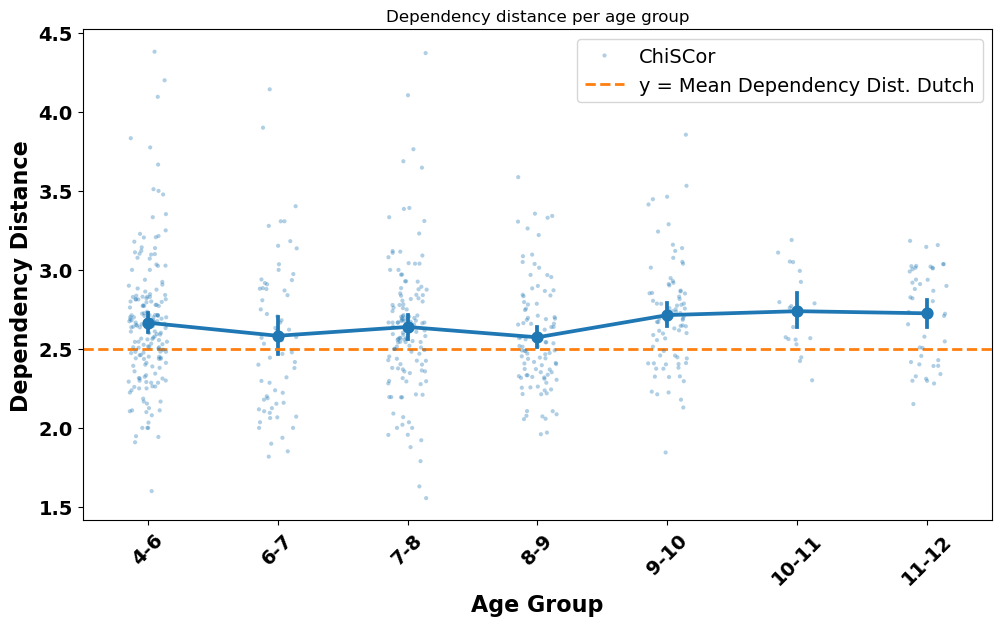

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path_name = '/Users/sabijn/Documents/PhD/Datasets/chisor_dataset_all/ChiSCor_CoNLL_paper/csv/ChiSCor_master_df_password/ChiSCor_master_df.csv'
df_chiscor = pd.read_csv(path_name, index_col=0)
df_chiscor = df_chiscor.rename(columns={'story_raw': 'story'})

# --- 2) Keep COMPLETE ChiSCor data (no mean aggregation) ---
df_chi = (
	df_chiscor.loc[:, ["agegroup_str", "dep_dist"]]
	  .rename(columns={"agegroup_str": "age_group"})
)
df_chi["source"] = "ChiSCor"

# --- 4) Sort age groups numerically by lower bound (works for "3_4", "10_12", etc.) ---
def lower_bound(x):
	return int(str(x).split("-")[0])

age_order = sorted(df_chi["age_group"].dropna().unique(), key=lower_bound)
print(df_chi)
# --- 5) Plot: raw points (with small separation between datasets) + point plot means ---
plt.figure(figsize=(10, 6))

# dodge=True creates the small horizontal separation between the two sources
sns.stripplot(
	data=df_chi,
	x="age_group", y="dep_dist",
	hue="source",
	order=age_order,
	jitter=0.15,         # small jitter within each dataset
	alpha=0.35,
	size=3
)

# Mean trend lines as a Seaborn point plot (solid circles + solid line)
sns.pointplot(
	data=df_chi,
	x="age_group", y="dep_dist",
	hue="source",
	order=age_order,
	estimator=np.mean,
	errorbar=("ci", 95),       # change to ("ci", 95) or ("se") if you want error bars
	markers="o",
	linestyles="-",
	capsize=0
)

# Reference line
plt.axhline(y=2.5, color="tab:orange", linestyle="--", linewidth=2,
			label="y = Mean Dependency Dist. Dutch")

# Aesthetics
plt.xlabel("Age Group", fontsize=16, fontweight='bold')
plt.ylabel("Dependency Distance", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()

# De-duplicate legend entries (because we used hue twice)
handles, labels = plt.gca().get_legend_handles_labels()
seen = set()
new_handles, new_labels = [], []
for h, l in zip(handles, labels):
	if l not in seen:
		new_handles.append(h)
		new_labels.append(l)
		seen.add(l)

plt.legend(new_handles, new_labels, title=None, fontsize=14)

ax = plt.gca()

# Make tick labels bigger
ax.tick_params(axis='both', which='major', labelsize=14)

for label in ax.get_xticklabels() + ax.get_yticklabels():
	label.set_fontweight('bold')

plt.title('Dependency distance per age group')
plt.savefig('results/paper_plots/dd_age_chiscor.pdf')
